# Análisis Exploratorio de Datos (EDA) — Dengue País × Semana
## Predicción de Brotes de Dengue en El Salvador
### Universidad de El Salvador — Ingeniería

Este notebook analiza el **dataset país × semana** (2014-2024), construido a partir de datos
epidemiológicos de **OpenDengue** (casos sospechosos a nivel nacional) integrados con datos
climáticos de **NASA POWER** promediados a nivel nacional.

**Diferencias respecto al dataset anterior (departamento × semana):**
- Cobertura nacional (no por departamento), resolución semanal
- Fuente OpenDengue: datos estandarizados, serie continua sin semanas faltantes
- Variable objetivo: casos SOSPECHOSOS (más numerosos, menos ceros, mejor señal)
- Cubre 2014-2024 con VARIOS años epidémicos (2014, 2015, 2019, 2022)

**Objetivos:**
1. Evaluar la calidad y continuidad de la serie temporal
2. Analizar la distribución de casos y su estacionalidad
3. Identificar y caracterizar los años epidémicos
4. Explorar la relación clima-dengue
5. Analizar correlaciones y preparar el modelado

## 1. Configuración e importación de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
sns.set_palette('viridis')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 2. Carga del dataset desde GitHub

In [ ]:
URL = 'https://raw.githubusercontent.com/Melvillalta1/DengueSV/refs/heads/main/dataset_pais_semana.csv'
df = pd.read_csv(URL)

# Crear un índice temporal continuo para graficar la serie
df = df.sort_values(['anio_epi','semana_epi']).reset_index(drop=True)
df['indice_temporal'] = range(len(df))

print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Período: {df.anio_epi.min()} - {df.anio_epi.max()}')
df.head()

Dimensiones: 574 filas x 39 columnas
Período: 2014 - 2024


,anio_epi,semana_epi,calendar_start_date,calendar_end_date,casos_dengue,t2m_max_sem,t2m_min_sem,t2m_prom_sem,precip_total,precip_dias_lluvia,humedad_prom,viento_prom,amplitud_termica,grados_dia,en_rango_optimo,dist_temp_optima,semana_lluviosa,estacion_lluviosa,semana_sin,semana_cos,t2m_prom_sem_lag1,t2m_prom_sem_lag2,t2m_prom_sem_lag3,t2m_prom_sem_lag4,precip_total_lag1,precip_total_lag2,precip_total_lag3,precip_total_lag4,humedad_prom_lag1,humedad_prom_lag2,humedad_prom_lag3,humedad_prom_lag4,casos_dengue_lag1,casos_dengue_lag2,casos_dengue_lag3,casos_dengue_lag4,casos_tendencia,casos_promedio_4sem,indice_temporal
0,2014,1,2013-12-29,2014-01-04,264,31.650104,21.321354,25.898958,0.462083,0.833333,64.026042,2.692917,10.328750,15.898958,1,1.101042,0,0,0.120537,0.992709,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2014,2,2014-01-05,2014-01-11,373,30.761369,20.648929,25.086964,1.235833,2.916667,63.385298,3.557321,10.112440,15.086964,1,1.913036,0,0,0.239316,0.970942,25.898958,NaN,NaN,NaN,0.462083,NaN,NaN,NaN,64.026042,NaN,NaN,NaN,264.0,NaN,NaN,NaN,NaN,264.000000,1
2,2014,3,2014-01-12,2014-01-18,373,31.106429,19.970298,24.833512,1.143750,2.875000,60.171786,3.780893,11.136131,14.833512,1,2.166488,0,0,0.354605,0.935016,25.086964,25.898958,NaN,NaN,1.235833,0.462083,NaN,NaN,63.385298,64.026042,NaN,NaN,373.0,264.0,NaN,NaN,109.0,318.500000,2
3,2014,4,2014-01-19,2014-01-25,358,31.781905,20.974940,25.701607,1.421250,2.708333,60.403810,3.939048,10.806964,15.701607,1,1.298393,0,0,0.464723,0.885456,24.833512,25.086964,25.898958,NaN,1.143750,1.235833,0.462083,NaN,60.171786,63.385298,64.026042,NaN,373.0,373.0,264.0,NaN,0.0,336.666667,3
4,2014,5,2014-01-26,2014-02-01,417,31.978095,21.739167,26.228929,0.382500,1.416667,61.786488,2.180000,10.238929,16.228929,1,0.771071,0,0,0.568065,0.822984,25.701607,24.833512,25.086964,25.898958,1.421250,1.143750,1.235833,0.462083,60.403810,60.171786,63.385298,64.026042,358.0,373.0,373.0,264.0,-15.0,342.000000,4


## 3. Estructura y estadísticas generales

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 574 entries, 0 to 573
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   anio_epi             574 non-null    int64  
 1   semana_epi           574 non-null    int64  
 2   calendar_start_date  574 non-null    object 
 3   calendar_end_date    574 non-null    object 
 4   casos_dengue         574 non-null    int64  
 5   t2m_max_sem          574 non-null    float64
 6   t2m_min_sem          574 non-null    float64
 7   t2m_prom_sem         574 non-null    float64
 8   precip_total         574 non-null    float64
 9   precip_dias_lluvia   574 non-null    float64
 10  humedad_prom         574 non-null    float64
 11  viento_prom          574 non-null    float64
 12  amplitud_termica     574 non-null    float64
 13  grados_dia           574 non-null    float64
 14  en_rango_optimo      574 non-null    int64  
 15  dist_temp_optima     574 non-null    flo

In [ ]:
# Estadísticas de la variable objetivo
print('=== VARIABLE OBJETIVO: casos_dengue ===')
print(df['casos_dengue'].describe().round(1))
print(f"\nTotal de casos en todo el período: {df['casos_dengue'].sum():,}")
print(f"Semanas con 0 casos: {(df['casos_dengue']==0).sum()} ({(df['casos_dengue']==0).mean()*100:.1f}%)")

=== VARIABLE OBJETIVO: casos_dengue ===
count     574.0
mean      339.2
std       492.8
min         0.0
25%        95.2
50%       150.0
75%       302.0
max      2897.0
Name: casos_dengue, dtype: float64

Total de casos en todo el período: 194,717
Semanas con 0 casos: 9 (1.6%)


**Nota:** A diferencia del dataset departamental anterior (que tenía muchísimos ceros),aquí los casos son nacionales y sospechosos, por lo que casi no hay semanas en cero. Estofacilita el modelado y da una señal más rica.

## 4. Calidad de la serie temporal: continuidad

In [ ]:
# Verificar cobertura por año
cobertura = df.groupby('anio_epi').agg(
    semanas=('semana_epi','count'),
    casos_totales=('casos_dengue','sum'),
    casos_promedio=('casos_dengue','mean'),
    casos_max=('casos_dengue','max'),
).round(1)
print('=== COBERTURA Y CASOS POR AÑO ===')
print(cobertura.to_string())

=== COBERTURA Y CASOS POR AÑO ===
          semanas  casos_totales  casos_promedio  casos_max
anio_epi                                                   
2014           53          53460          1008.7       2897
2015           52          50169           964.8       2478
2016           52           8789           169.0        437
2017           52           4297            82.6        166
2018           52           8448           162.5        390
2019           52          27470           528.3       2178
2020           53           5450           102.8        256
2021           52           5752           110.6        190
2022           52          16542           318.1        710
2023           52           5788           111.3        281
2024           52           8552           164.5        278


## 5. Serie temporal completa (la vista más importante)

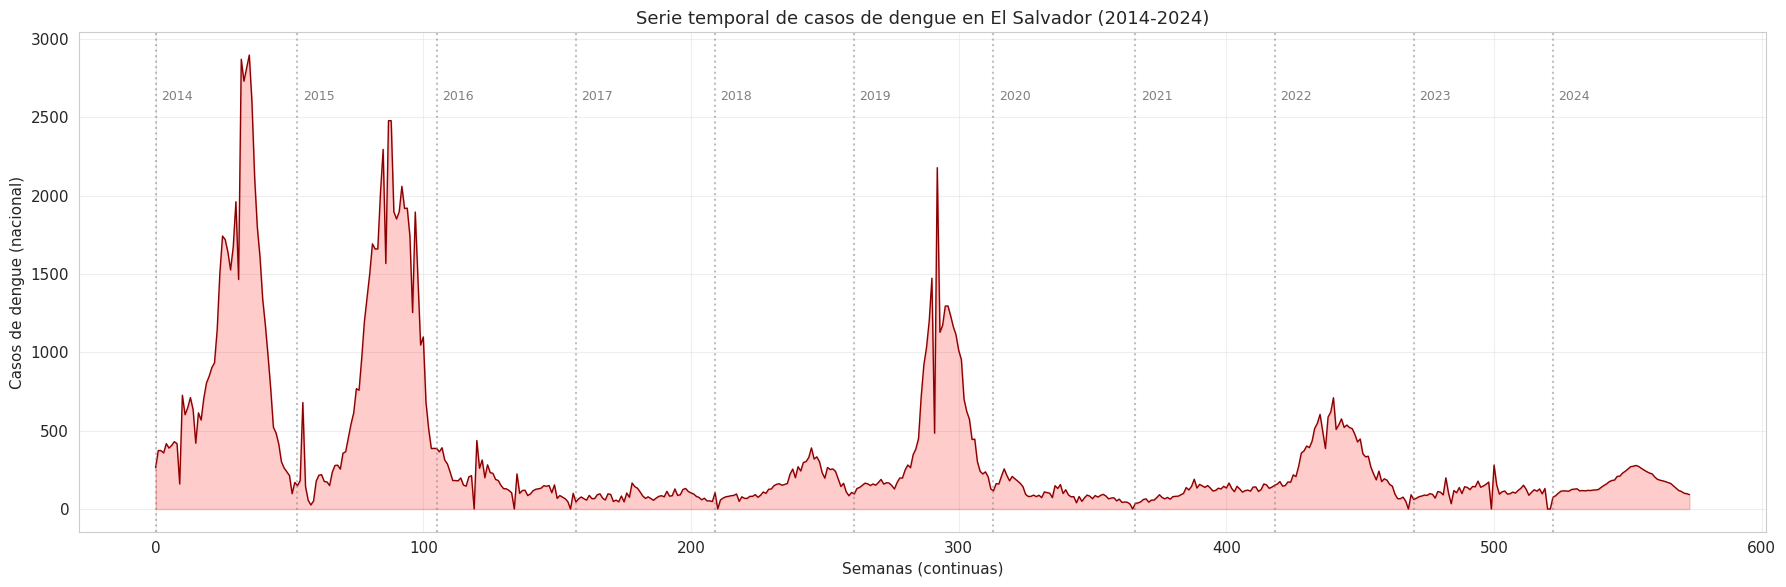

In [ ]:
# Graficar toda la serie de casos a lo largo del tiempo
plt.figure(figsize=(18, 6))
plt.plot(df['indice_temporal'], df['casos_dengue'], color='darkred', linewidth=1)
plt.fill_between(df['indice_temporal'], df['casos_dengue'], alpha=0.2, color='red')

# Marcar el inicio de cada año
for anio in sorted(df['anio_epi'].unique()):
    idx = df[df['anio_epi']==anio]['indice_temporal'].min()
    plt.axvline(idx, color='gray', linestyle=':', alpha=0.5)
    plt.text(idx+2, df['casos_dengue'].max()*0.9, str(anio), fontsize=9, color='gray')

plt.title('Serie temporal de casos de dengue en El Salvador (2014-2024)', fontsize=13)
plt.xlabel('Semanas (continuas)')
plt.ylabel('Casos de dengue (nacional)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Distribución de los casos

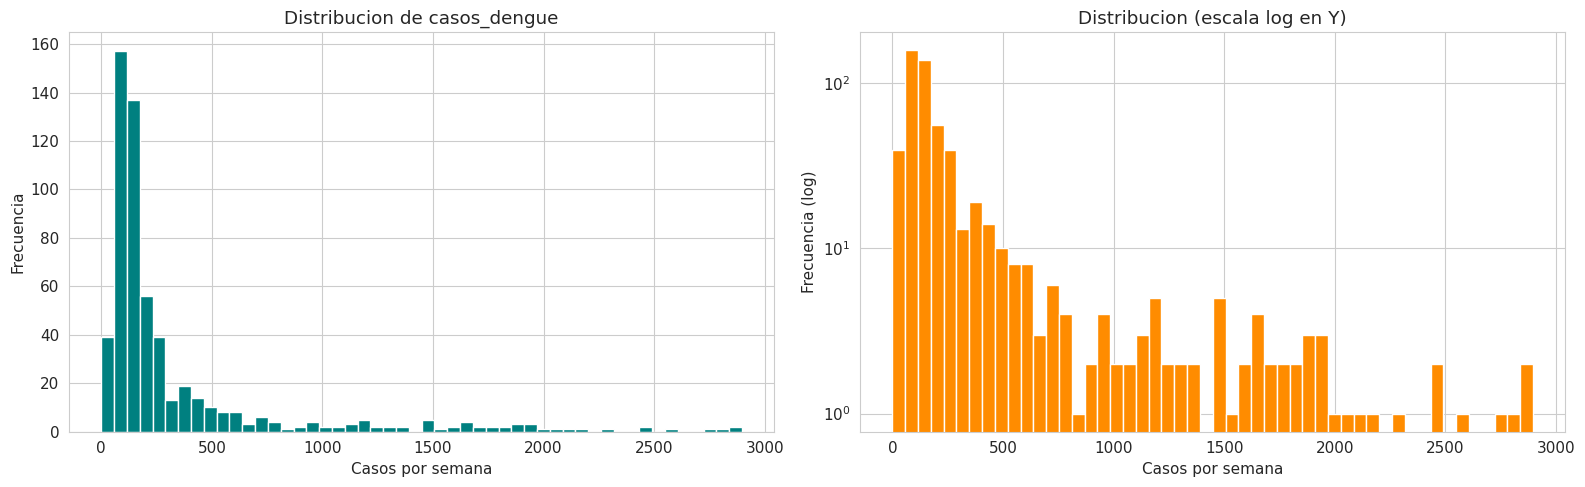

Media: 339.2 | Mediana: 150.0
Máximo: 2897 | Mínimo: 0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(df['casos_dengue'], bins=50, color='teal', edgecolor='white')
axes[0].set_title('Distribucion de casos_dengue')
axes[0].set_xlabel('Casos por semana'); axes[0].set_ylabel('Frecuencia')

axes[1].hist(df['casos_dengue'], bins=50, color='darkorange', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Distribucion (escala log en Y)')
axes[1].set_xlabel('Casos por semana'); axes[1].set_ylabel('Frecuencia (log)')
plt.tight_layout(); plt.show()

print(f"Media: {df['casos_dengue'].mean():.1f} | Mediana: {df['casos_dengue'].median():.1f}")
print(f"Máximo: {df['casos_dengue'].max()} | Mínimo: {df['casos_dengue'].min()}")

## 7. Estacionalidad: patrón promedio por semana del año

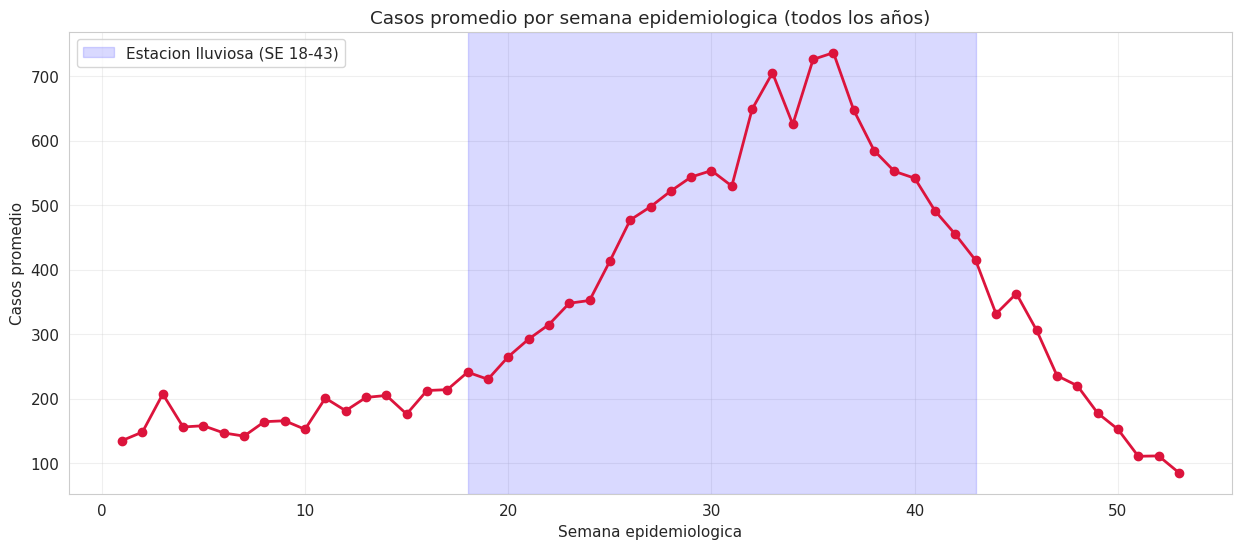

In [ ]:
estacional = df.groupby('semana_epi')['casos_dengue'].mean()
plt.figure(figsize=(15, 6))
plt.plot(estacional.index, estacional.values, marker='o', color='crimson', linewidth=2)
plt.axvspan(18, 43, alpha=0.15, color='blue', label='Estacion lluviosa (SE 18-43)')
plt.title('Casos promedio por semana epidemiologica (todos los años)')
plt.xlabel('Semana epidemiologica'); plt.ylabel('Casos promedio')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

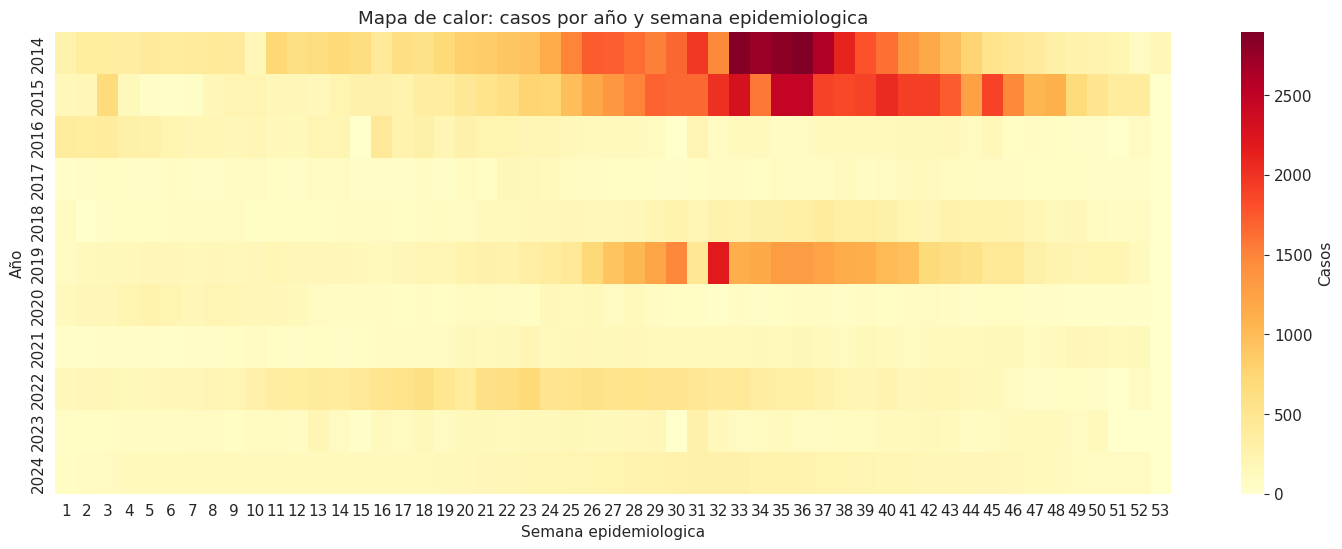

In [ ]:
# Heatmap año x semana
pivot = df.pivot_table(values='casos_dengue', index='anio_epi',
                        columns='semana_epi', aggfunc='sum', fill_value=0)
plt.figure(figsize=(18, 6))
sns.heatmap(pivot, cmap='YlOrRd', cbar_kws={'label':'Casos'})
plt.title('Mapa de calor: casos por año y semana epidemiologica')
plt.xlabel('Semana epidemiologica'); plt.ylabel('Año'); plt.show()

**Interpretación esperada:** El heatmap permite ver qué años fueron epidémicos (filasmás intensas) y en qué semanas se concentran los casos. Los años 2014, 2015, 2019 y 2022 deberíandestacar. La banda de temporada lluviosa debería mostrar mayor intensidad.

## 8. Comparación de años epidémicos vs no epidémicos

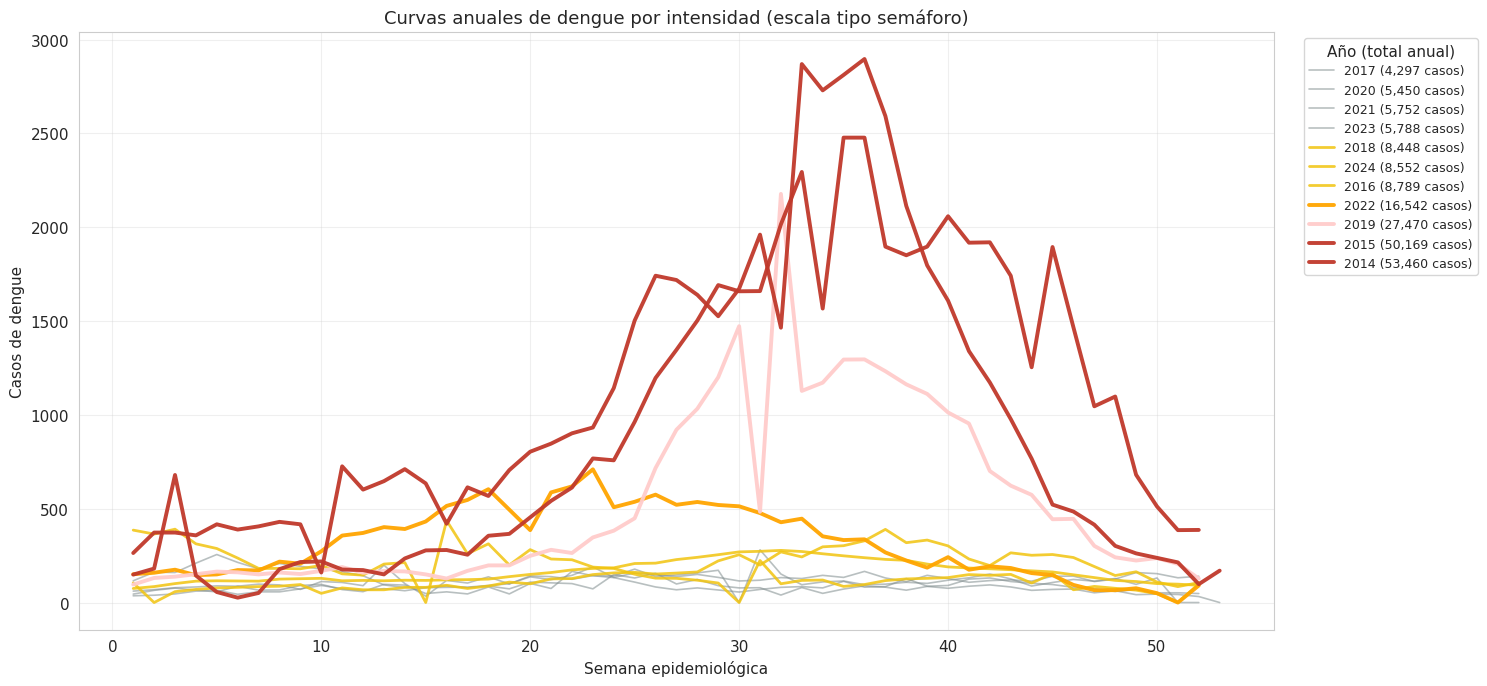

Clasificación de años por intensidad:
  2014:  53,460 casos
  2015:  50,169 casos
  2019:  27,470 casos
  2022:  16,542 casos
  2016:   8,789 casos
  2024:   8,552 casos
  2018:   8,448 casos
  2023:   5,788 casos
  2021:   5,752 casos
  2020:   5,450 casos
  2017:   4,297 casos


In [ ]:

# Clasificar años por intensidad y asignar colores tipo semáforo
# Calcular el total de casos de cada año para ordenar la intensidad
totales_anio = df.groupby('anio_epi')['casos_dengue'].sum().sort_values(ascending=False)

# Definir umbrales para el semáforo (basados en los casos totales anuales)
def color_semaforo(casos_totales):
    if casos_totales >= 40000:      # epidemia severa
        return '#C0392B'            # rojo intenso
    elif casos_totales >= 20000:    # epidemia
        return '#FFCCCB'            # rojo
    elif casos_totales >= 12000:    # brote moderado-alto
        return '#FFA500'            # naranja
    elif casos_totales >= 8000:     # transmisión elevada
        return '#F1C40F'            # amarillo
    else:                           # transmisión normal/baja
        return '#7F8C8D'            # verde-gris

plt.figure(figsize=(15, 7))

# Ordenar años de menor a mayor intensidad para que los picos altos queden al frente
anios_ordenados = totales_anio.sort_values().index.tolist()

for anio in anios_ordenados:
    datos_anio = df[df['anio_epi']==anio].sort_values('semana_epi')
    total = totales_anio[anio]
    color = color_semaforo(total)
    # Los años de mayor intensidad más gruesos y opacos; los normales más tenues
    if total >= 12000:
        lw, alpha, z = 2.8, 0.95, 3
    elif total >= 8000:
        lw, alpha, z = 2.0, 0.85, 2
    else:
        lw, alpha, z = 1.2, 0.55, 1
    plt.plot(datos_anio['semana_epi'], datos_anio['casos_dengue'],
             color=color, linewidth=lw, alpha=alpha, zorder=z,
             label=f'{anio} ({total:,} casos)')

plt.title('Curvas anuales de dengue por intensidad (escala tipo semáforo)', fontsize=13)
plt.xlabel('Semana epidemiológica')
plt.ylabel('Casos de dengue')
plt.legend(title='Año (total anual)', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar la clasificación de cada año
print('Clasificación de años por intensidad:')
for anio, total in totales_anio.items():
    print(f'  {anio}: {total:>7,} casos')

## 9. Comportamiento del clima a nivel nacional

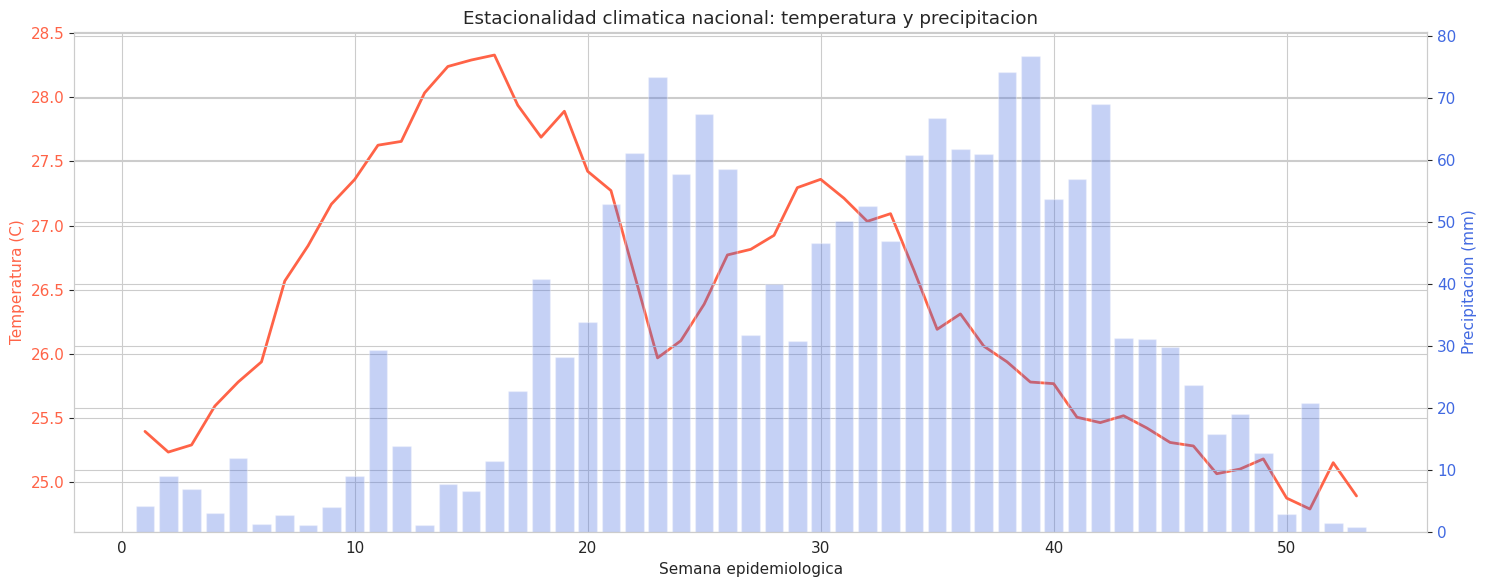

In [ ]:
fig, ax1 = plt.subplots(figsize=(15, 6))
temp = df.groupby('semana_epi')['t2m_prom_sem'].mean()
precip = df.groupby('semana_epi')['precip_total'].mean()
ax1.plot(temp.index, temp.values, color='tomato', linewidth=2, label='Temp. promedio')
ax1.set_xlabel('Semana epidemiologica'); ax1.set_ylabel('Temperatura (C)', color='tomato')
ax1.tick_params(axis='y', labelcolor='tomato')
ax2 = ax1.twinx()
ax2.bar(precip.index, precip.values, alpha=0.3, color='royalblue', label='Precipitacion')
ax2.set_ylabel('Precipitacion (mm)', color='royalblue')
ax2.tick_params(axis='y', labelcolor='royalblue')
plt.title('Estacionalidad climatica nacional: temperatura y precipitacion')
fig.tight_layout(); plt.show()

## 10. Relación clima-dengue

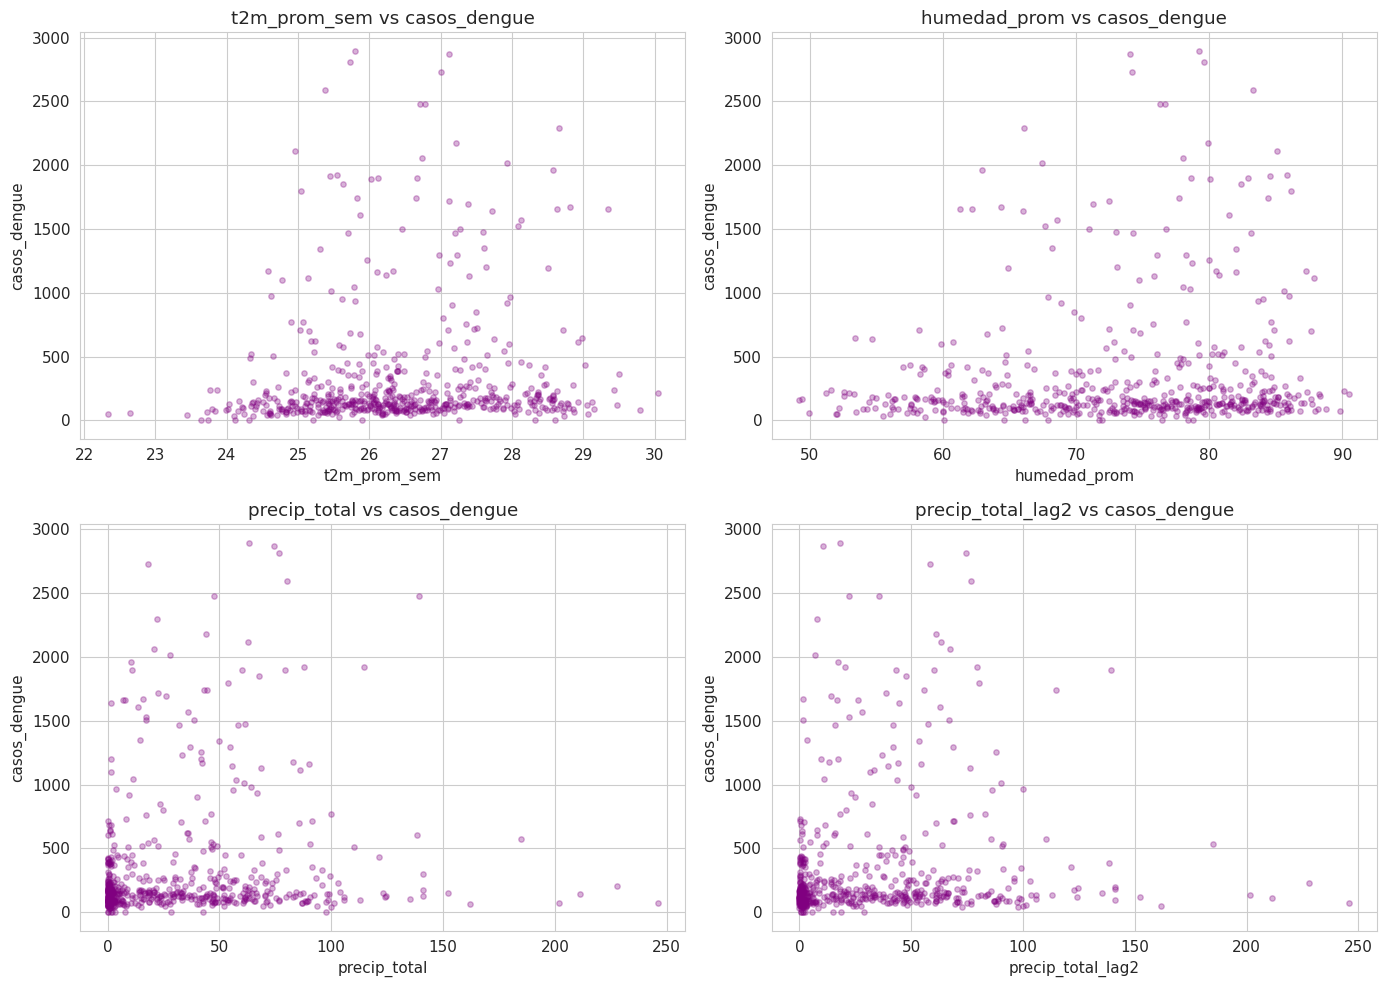

In [ ]:
rel_vars = ['t2m_prom_sem', 'humedad_prom', 'precip_total', 'precip_total_lag2']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, var in zip(axes.flat, rel_vars):
    ax.scatter(df[var], df['casos_dengue'], alpha=0.3, s=15, color='purple')
    ax.set_xlabel(var); ax.set_ylabel('casos_dengue')
    ax.set_title(f'{var} vs casos_dengue')
plt.tight_layout(); plt.show()

## 11. Matriz de correlación

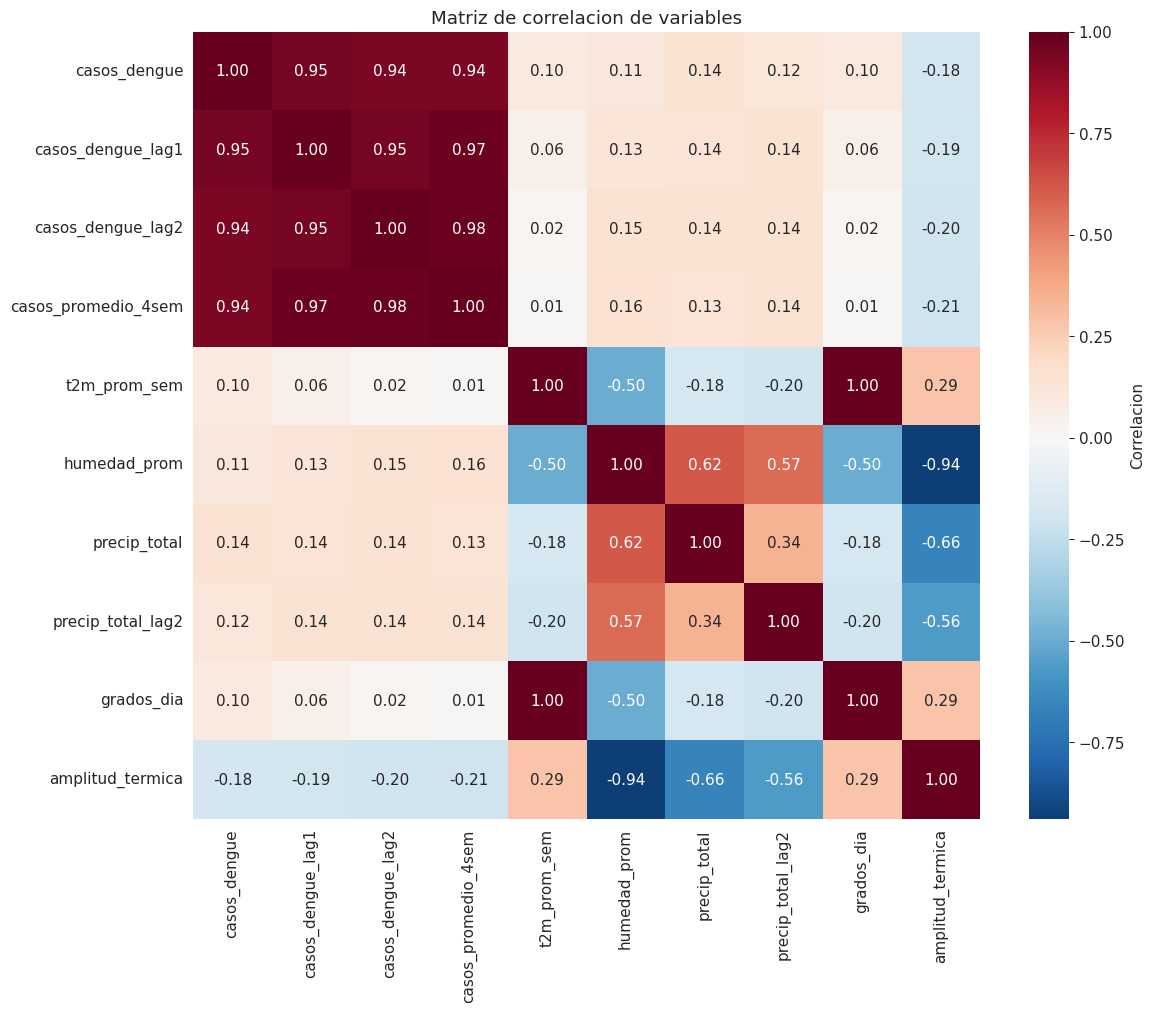

In [ ]:
cols_corr = ['casos_dengue', 'casos_dengue_lag1', 'casos_dengue_lag2',
             'casos_promedio_4sem', 't2m_prom_sem', 'humedad_prom',
             'precip_total', 'precip_total_lag2', 'grados_dia', 'amplitud_termica']
corr = df[cols_corr].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True,
            cbar_kws={'label':'Correlacion'})
plt.title('Matriz de correlacion de variables')
plt.tight_layout(); plt.show()

In [ ]:
corr_casos = df[cols_corr].corr()['casos_dengue'].drop('casos_dengue').sort_values(ascending=False)
print('Correlacion de cada variable con casos_dengue:')
print(corr_casos.to_string())

Correlacion de cada variable con casos_dengue:
casos_dengue_lag1      0.948682
casos_promedio_4sem    0.937844
casos_dengue_lag2      0.937310
precip_total           0.136833
precip_total_lag2      0.118189
humedad_prom           0.112520
grados_dia             0.096041
t2m_prom_sem           0.096041
amplitud_termica      -0.182373


**Interpretación esperada:** Los rezagos de casos (casos_dengue_lag1, casos_promedio_4sem)deberían tener correlaciones muy altas con los casos actuales, confirmando la fuerte autocorrelacióntemporal del dengue. Las variables climáticas mostrarán correlaciones más débiles pero relevantes.

## 12. Conclusiones del EDADocumenta aquí los hallazgos:### Sobre la calidad de los datos- Serie continua de 574 semanas (2014-2024), sin semanas faltantes- Fuente OpenDengue: casos sospechosos nacionales, estandarizados- Muy pocos o ningún cero, a diferencia del dataset departamental anterior### Sobre los años epidémicos- **Años epidémicos identificados:** 2014, 2015, 2019, 2022- Múltiples brotes permiten al modelo aprender mejor la dinámica de epidemias- **Ventaja sobre el dataset anterior:** ya no hay un solo pico aislado (2015) que domine### Sobre la estacionalidad- Los casos se concentran en la temporada lluviosa (SE 18-43)- El patrón es consistente con el ciclo del mosquito### Sobre las correlaciones- **Predictores más fuertes:** _(completar — deberían ser los rezagos de casos)_- **Variables climáticas relevantes:** _(completar)_### Consideraciones para el modelado- Con varios años epidémicos, se puede elegir un año de brote como prueba (ej. 2022)  para evaluar la capacidad de detectar epidemias, algo que no era posible antes- La división debe seguir siendo cronológica (respetar el orden temporal)### Próximos pasos1. Definir la división train/val/test cronológica2. Entrenar modelos (Regresión Lineal, Random Forest, XGBoost)3. Comparar con los resultados del enfoque departamental anterior

## 13. Patrón estacional promedio: casos vs clima

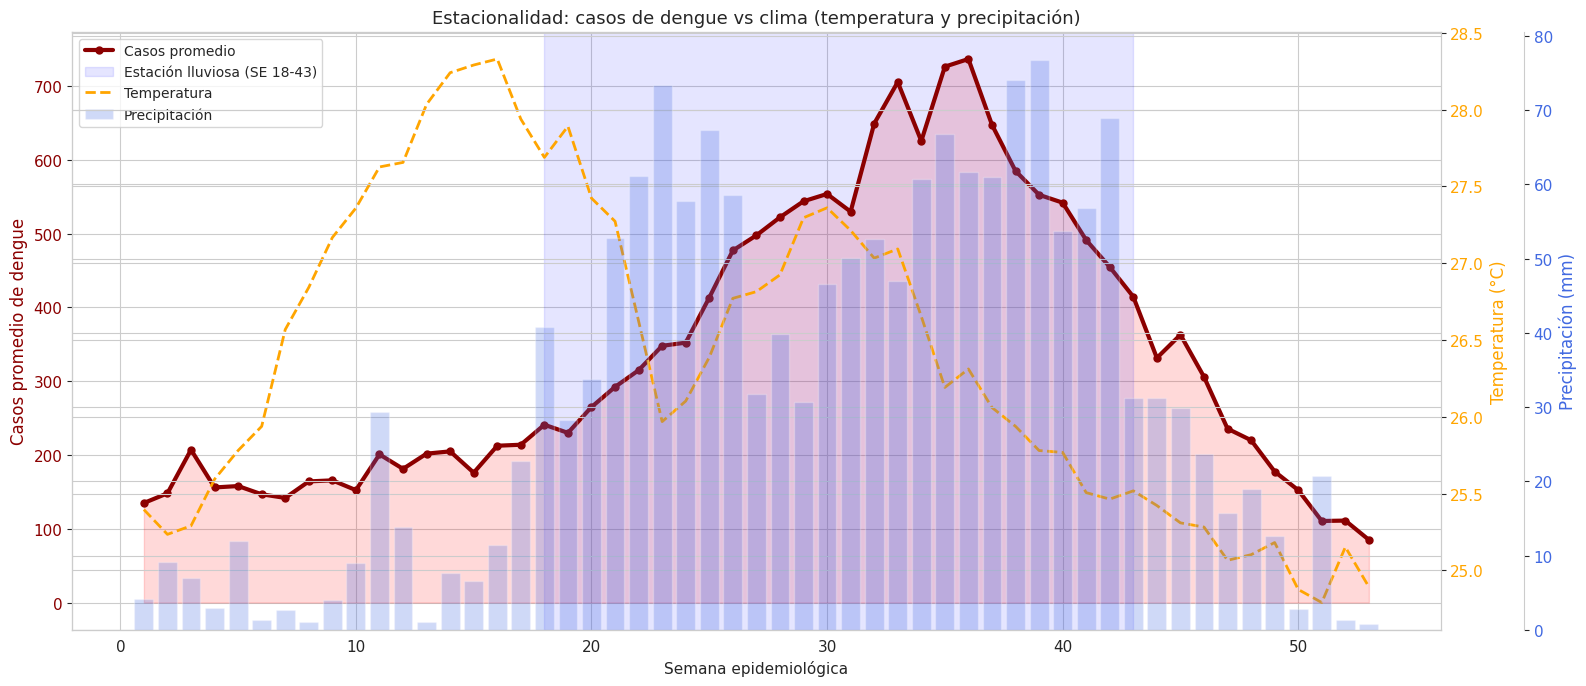

In [ ]:
# Gráfica: casos promedio + clima por semana epidemiológica (patrón estacional)
casos_sem = df.groupby('semana_epi')['casos_dengue'].mean()
temp_sem = df.groupby('semana_epi')['t2m_prom_sem'].mean()
precip_sem = df.groupby('semana_epi')['precip_total'].mean()

fig, ax1 = plt.subplots(figsize=(16, 7))

# Eje 1: casos (línea roja gruesa, protagonista)
ax1.plot(casos_sem.index, casos_sem.values, color='darkred', linewidth=3,
         marker='o', markersize=5, label='Casos promedio', zorder=3)
ax1.fill_between(casos_sem.index, casos_sem.values, alpha=0.15, color='red')
ax1.set_xlabel('Semana epidemiológica')
ax1.set_ylabel('Casos promedio de dengue', color='darkred', fontsize=12)
ax1.tick_params(axis='y', labelcolor='darkred')

# Banda de temporada lluviosa
ax1.axvspan(18, 43, alpha=0.10, color='blue', label='Estación lluviosa (SE 18-43)')

# Eje 2: temperatura
ax2 = ax1.twinx()
ax2.plot(temp_sem.index, temp_sem.values, color='orange', linewidth=2,
         linestyle='--', label='Temperatura', zorder=2)
ax2.set_ylabel('Temperatura (°C)', color='orange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='orange')

# Eje 3: precipitación (barras al fondo)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.bar(precip_sem.index, precip_sem.values, alpha=0.25, color='royalblue',
        label='Precipitación', zorder=1)
ax3.set_ylabel('Precipitación (mm)', color='royalblue', fontsize=12)
ax3.tick_params(axis='y', labelcolor='royalblue')

# Leyenda combinada
lineas1, etiq1 = ax1.get_legend_handles_labels()
lineas2, etiq2 = ax2.get_legend_handles_labels()
lineas3, etiq3 = ax3.get_legend_handles_labels()
ax1.legend(lineas1+lineas2+lineas3, etiq1+etiq2+etiq3, loc='upper left', fontsize=10)

plt.title('Estacionalidad: casos de dengue vs clima (temperatura y precipitación)', fontsize=13)
fig.tight_layout()
plt.show()

14 Serie temporal completa: casos vs precipitación en el tiempo real

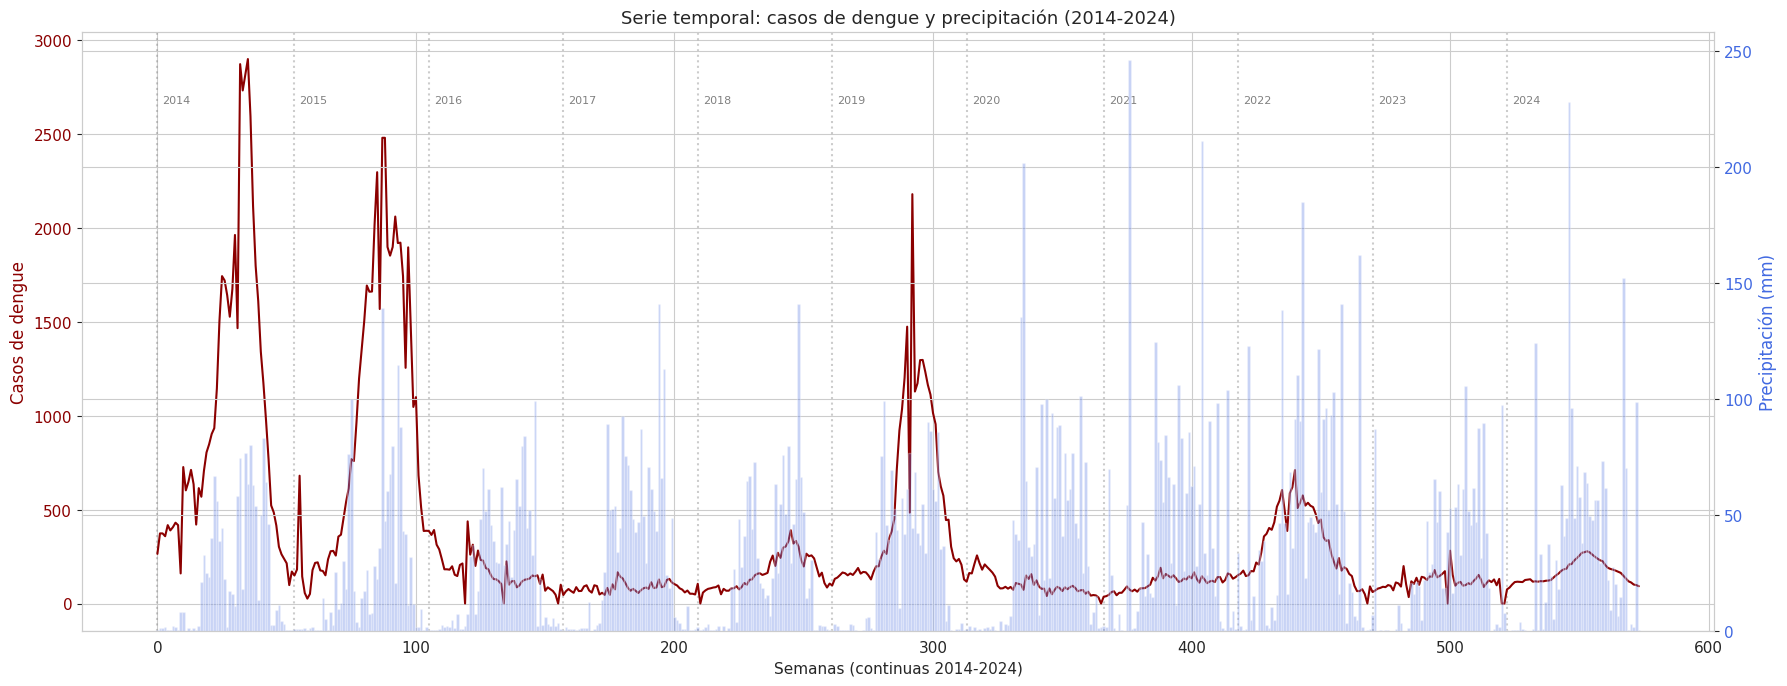

In [ ]:
# Serie temporal completa: casos vs precipitación a lo largo de los años
fig, ax1 = plt.subplots(figsize=(18, 7))

ax1.plot(df['indice_temporal'], df['casos_dengue'], color='darkred',
         linewidth=1.5, label='Casos de dengue', zorder=3)
ax1.set_xlabel('Semanas (continuas 2014-2024)')
ax1.set_ylabel('Casos de dengue', color='darkred', fontsize=12)
ax1.tick_params(axis='y', labelcolor='darkred')

ax2 = ax1.twinx()
ax2.bar(df['indice_temporal'], df['precip_total'], alpha=0.3, color='royalblue',
        width=1.0, label='Precipitación', zorder=1)
ax2.set_ylabel('Precipitación (mm)', color='royalblue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='royalblue')

# Marcar los años
for anio in sorted(df['anio_epi'].unique()):
    idx = df[df['anio_epi']==anio]['indice_temporal'].min()
    ax1.axvline(idx, color='gray', linestyle=':', alpha=0.4)
    ax1.text(idx+2, df['casos_dengue'].max()*0.92, str(anio), fontsize=8, color='gray')

plt.title('Serie temporal: casos de dengue y precipitación (2014-2024)', fontsize=13)
fig.tight_layout()
plt.show()